In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

# dependencies
pip install fvcore==0.1.5.post20221221
pip install 'git+https://github.com/facebookresearch/detectron2.git'


# Verify Detectron2 installation
import detectron2
print("Detectron2 installed successfully!")

#  libraries
import os
import cv2
import random
import numpy as np
from google.colab.patches import cv2_imshow
import torch
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog
from pycocotools.coco import COCO
import matplotlib.pyplot as plt


  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-a2q3puoe
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-a2q3puoe
  Resolved https://github.com/facebookresearch/detectron2.git to commit b1c43ffbc995426a9a6b5c667730091a384e0fa4
  Preparing metadata (setup.py) ... done
Detectron2 installed successfully!


In [3]:
# Dataset path
dataset_path = "/content/drive/MyDrive/File1"
coco_json = os.path.join(dataset_path, "coco_annotations_damages.json")
image_dir = os.path.join(dataset_path, "img")

# Register  dataset
register_coco_instances("File1", {}, coco_json, image_dir)

# Verify dataset
metadata = MetadataCatalog.get("File1")
dataset_dicts = DatasetCatalog.get("File1")



In [4]:
#confirmation
metadata = MetadataCatalog.get("File1")
print("Classes in metadata:", metadata.thing_classes)


Classes in metadata: ['Dent', 'Broken part', 'Scratch', 'Missing part', 'Paint chip', 'Corrosion', 'Flaking', 'Cracked']


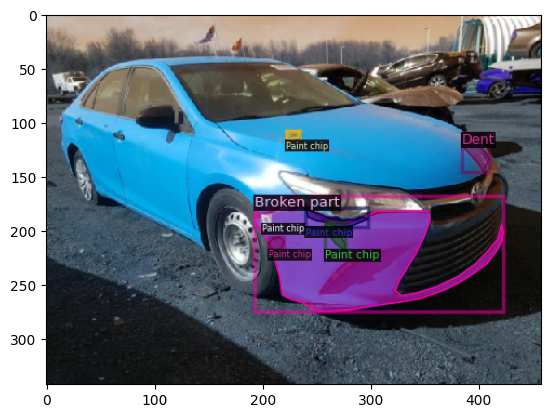

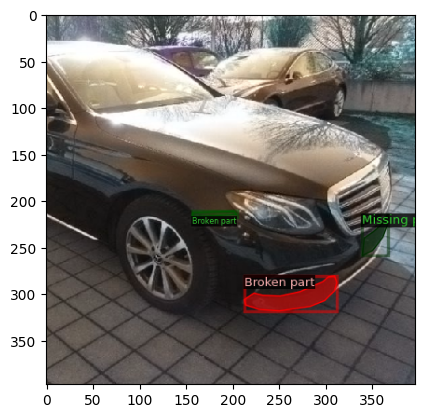

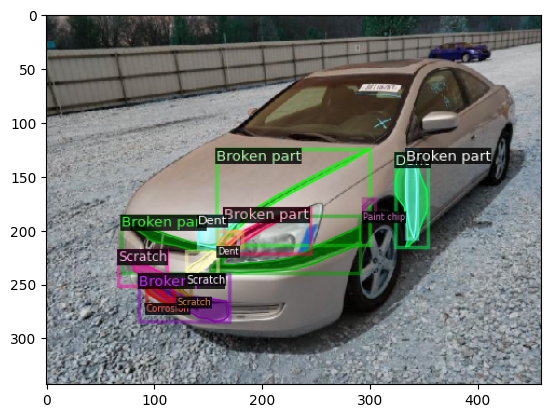

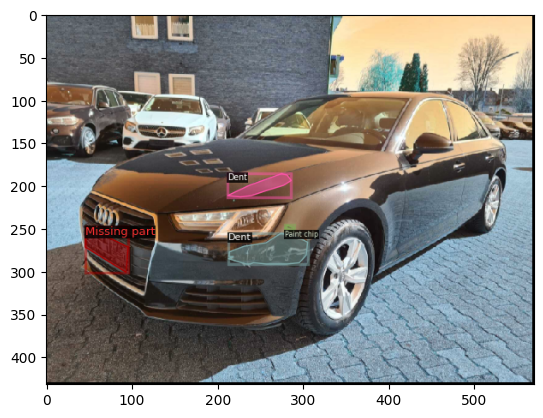

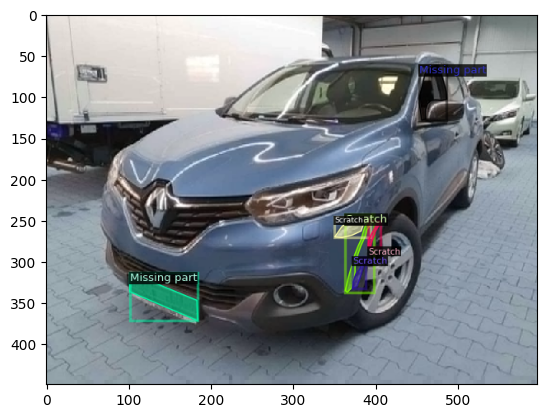

In [5]:
# Visualize some samples
for d in random.sample(dataset_dicts, 5):
    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=metadata, scale=0.8)
    vis = visualizer.draw_dataset_dict(d)
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.show()


SPLIT THE DATASET

In [6]:
from detectron2.data import DatasetCatalog

# Load dataset
dataset = DatasetCatalog.get("File1")
print(f"Total images in dataset: {len(dataset)}")


Total images in dataset: 814


In [7]:
import random

# Set seed for reproducibility
random.seed(42)

# Shuffle dataset
random.shuffle(dataset)

# Define split ratios
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Calculate split indices
train_size = int(len(dataset) * train_ratio)
val_size = int(len(dataset) * val_ratio)

# Split the dataset
train_dataset = dataset[:train_size]
val_dataset = dataset[train_size:train_size + val_size]
test_dataset = dataset[train_size + val_size:]

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 651, Val: 81, Test: 82


In [8]:
from detectron2.data import DatasetCatalog, MetadataCatalog

# Register each split
DatasetCatalog.register("File1_train", lambda: train_dataset)
DatasetCatalog.register("File1_val", lambda: val_dataset)
DatasetCatalog.register("File1_test", lambda: test_dataset)


# Metadata
thing_classes = ['Dent', 'Broken part', 'Scratch', 'Missing part', 'Paint chip', 'Corrosion', 'Flaking', 'Cracked']

MetadataCatalog.get("File1_train").set(thing_classes=thing_classes)
MetadataCatalog.get("File1_val").set(thing_classes=thing_classes)
MetadataCatalog.get("File1_test").set(thing_classes=thing_classes)


namespace(name='File1_test',
          thing_classes=['Dent',
                         'Broken part',
                         'Scratch',
                         'Missing part',
                         'Paint chip',
                         'Corrosion',
                         'Flaking',
                         'Cracked'])

INSTALLING DEPENDENCIES

In [9]:

# Download the Detectron2 configuration
!wget -O /content/drive/MyDrive/File1/mask_rcnn_R_50_FPN_3x.yaml https://raw.githubusercontent.com/facebookresearch/detectron2/main/configs/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml


--2025-01-10 12:23:37--  https://raw.githubusercontent.com/facebookresearch/detectron2/main/configs/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 192 [text/plain]
Saving to: ‘/content/drive/MyDrive/File1/mask_rcnn_R_50_FPN_3x.yaml’

/content/drive/MyDr 100%[===================>]     192  --.-KB/s    in 0s      

2025-01-10 12:23:37 (4.05 MB/s) - ‘/content/drive/MyDrive/File1/mask_rcnn_R_50_FPN_3x.yaml’ saved [192/192]



In [ ]:
import os
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.evaluation import COCOEvaluator
from detectron2.data import build_detection_test_loader
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.data import MetadataCatalog, DatasetCatalog


from detectron2.evaluation import inference_on_dataset

# Initialize configuration
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

# Use pre-trained weights from COCO
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

# Dataset configurations
cfg.DATASETS.TRAIN = ("File1_train",)  # Training dataset
cfg.DATASETS.TEST = ("File1_val",)    # Validation dataset
cfg.DATALOADER.NUM_WORKERS = 2        # Number of data loader workers (set to 2 for compatibility)

# Solver (Optimizer) settings
cfg.SOLVER.IMS_PER_BATCH = 2          # Batch size (images per batch)
cfg.SOLVER.BASE_LR = 0.00025          # Learning rate
cfg.SOLVER.MAX_ITER = 5000           # Total number of iterations
cfg.SOLVER.STEPS = (2500, 2800)       # ecay learning rate
cfg.SOLVER.CHECKPOINT_PERIOD = 500    # check after 500 times

# ROI heads (Region of Interest) settings
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 8
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512  # Proposals per image for training

# Output directory
cfg.OUTPUT_DIR = "/content/drive/MyDrive/File1/car_damage_output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Evaluation settings
cfg.TEST.EVAL_PERIOD = 500
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.70  # Confidence threshold for evaluation

# Log configuration
with open(os.path.join(cfg.OUTPUT_DIR, "config.yaml"), "w") as f:
    f.write(cfg.dump())
print("Configuration loaded and saved:", cfg)

# Train the model
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

# Evaluate the model on the validation dataset
print("Evaluating the model on the validation set...")
evaluator = COCOEvaluator("File1_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "File1_val")
validation_results = inference_on_dataset(trainer.model, val_loader, evaluator)
print(validation_results)

# Load the trained model for predictions
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.55 # Set a score threshold for predictions
predictor = DefaultPredictor(cfg)

# Test the model on the test set (if available)
if "File1_test" in DatasetCatalog.list():
    print("Testing the model on the test set...")
    evaluator = COCOEvaluator("File1_test", cfg, False, output_dir=cfg.OUTPUT_DIR)
    test_loader = build_detection_test_loader(cfg, "File1_test")
    test_results = inference_on_dataset(predictor.model, test_loader, evaluator)
    print(test_results)
else:
    print("Test set not found.")


Configuration loaded and saved: CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 2
  REPEAT_SQRT: True
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('File1_val',)
  TRAIN: ('File1_train',)
FLOAT32_PRECISION: 
GLOBAL:
  HACK: 1.0
INPUT:
  CROP:
    ENABLED: False
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  FORMAT: BGR
  MASK_FORMAT: polygon
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (640, 672, 704, 736, 768, 800)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32], [64], [128], [256], [512]]
  BACKBONE:
    FREEZE_AT: 2
    NAME: build_resnet_fpn_backbone
  D

roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[01/10 12:23:39 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.10/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[01/10 12:23:53 d2.utils.events]:  eta: 0:48:23  iter: 19  total_loss: 5.561  loss_cls: 2.133  loss_box_reg: 0.07351  loss_mask: 0.6941  loss_rpn_cls: 2.454  loss_rpn_loc: 0.2013    time: 0.6060  last_time: 0.7785  data_time: 0.0393  last_data_time: 0.0578   lr: 4.9953e-06  max_mem: 2579M


EXPORT MODEL

In [ ]:
torch.save(trainer.model.state_dict(), "/content/drive/MyDrive/File1/final_model.pth")
with open("/content/drive/MyDrive/File1/config.yaml", "w") as f:
    f.write(cfg.dump())


VISUALISE SOME TEST IMAGES

In [ ]:
from google.colab.patches import cv2_imshow
from detectron2.utils.visualizer import Visualizer
import cv2
import random

# Load metadata and dataset
dataset_dicts = DatasetCatalog.get("File1_val")
metadata = MetadataCatalog.get("File1_val")

# Visualize 3 random samples from the dataset
for d in random.sample(dataset_dicts, 7):  # Adjust the number as needed
    img = cv2.imread(d["file_name"])
    outputs = predictor(img)

    # Use Visualizer to draw predictions on the image
    v = Visualizer(img[:, :, ::-1], metadata=metadata, scale=1.2)
    v = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    # Display the image in Colab
    cv2_imshow(v.get_image()[:, :, ::-1])


In [ ]:

pip install flask flask-ngrok opencv-python-headless detectron2


In [ ]:
pip install pyngrok
ngrok authtoken 2pP3k5banwti2kXJLSOyhfXJqs9_6Beqddg1b5bLmUQvCf8rZ


In [ ]:


from detectron2.evaluation import inference_on_dataset

from flask import Flask, request, jsonify, send_file
import cv2
import numpy as np
import io
from PIL import Image
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from pyngrok import ngrok

app = Flask(__name__)

# Load the trained model
cfg = get_cfg()
cfg.merge_from_file("/content/drive/MyDrive/File1/config.yaml")  # Path to your config file
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/File1/final_model.pth"  # Path to your trained weights
predictor = DefaultPredictor(cfg)

# Metadata for visualization
metadata = MetadataCatalog.get(cfg.DATASETS.TRAIN[0])

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Get binary image from the request
        image_binary = request.data

        # Decode binary data into an image
        np_arr = np.frombuffer(image_binary, np.uint8)
        image = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

        # Run inference
        outputs = predictor(image)

        # Parse predictions
        instances = outputs["instances"].to("cpu")
        predictions = {
            "boxes": instances.pred_boxes.tensor.numpy().tolist() if instances.has("pred_boxes") else [],
            "scores": instances.scores.numpy().tolist() if instances.has("scores") else [],
            "classes": instances.pred_classes.numpy().tolist() if instances.has("pred_classes") else [],
        }

        # Visualize predictions on the image
        v = Visualizer(image[:, :, ::-1], metadata=metadata, scale=0.5)
        v = v.draw_instance_predictions(instances)
        result_image = v.get_image()[:, :, ::-1]

        # Convert the visualized image to binary for response
        _, buffer = cv2.imencode('.jpg', result_image)
        response_image = io.BytesIO(buffer)
        response_image.seek(0)

        # Send response with image and predictions
        return jsonify({
            "predictions": predictions,  # JSON metadata
            "image": buffer.tobytes().decode("latin1"),  # Encoded image
        }), 200

    except Exception as e:
        return jsonify({"error": str(e)}), 400


if __name__ == '__main__':
    # Start Ngrok tunnel
    public_url = ngrok.connect(5000)
    print("Ngrok Tunnel URL:", public_url)

    # Start Flask app
    app.run(port=5000)
